**Importing Necessory Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
import sklearn.metrics as metrics

**Mounting with Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/DS_H_Features Face_Parts/DS_H_Features LeftFace(VS).csv'
df = pd.read_csv(file_path)

In [ ]:
df.head()

,image_name,0,1,2,3,4,5,6,7,8,...,2039,2040,2041,2042,2043,2044,2045,2046,2047,DownSyndromeStatus
0,LeftFace(VS)_down_599.jpg,0.008877,0.090835,0.000000,2.743675,2.567852,0.0,0.083237,0.053190,0.000000,...,0.049192,0.714736,1.922644,0.000000,0.000000,0.006069,0.028173,0.020907,0.434424,1
1,LeftFace(VS)_down_543.jpg,0.048340,0.002716,0.000000,1.212387,2.258635,0.0,0.037701,0.000058,0.052278,...,0.135460,0.446271,0.000000,0.026483,0.000000,0.156230,0.000000,0.000000,0.048527,1
2,LeftFace(VS)_down_545.jpg,0.082830,0.017456,0.000000,0.910998,1.628066,0.0,0.113962,2.146062,0.181890,...,0.247923,0.480801,0.000000,0.009301,0.057729,0.030665,0.084962,0.000000,0.041800,1
3,LeftFace(VS)_down_588.jpg,0.005250,0.000000,0.045274,2.275857,2.101627,0.0,0.922893,0.435529,0.000000,...,0.000000,0.869707,0.729126,0.239466,0.000000,0.042234,0.043776,0.052511,0.002425,1
4,LeftFace(VS)_down_601.jpg,0.041643,0.023273,0.000000,2.991538,0.759331,0.0,0.243715,0.041768,0.000000,...,0.014044,0.000000,0.413413,0.112697,0.000000,0.000000,0.118830,0.004222,0.010776,1


In [ ]:
#checking for null values
df.isnull().sum()

,0
image_name,0
0,0
1,0
2,0
3,0
...,...
2044,0
2045,0
2046,0
2047,0


In [ ]:
#null value count
df.isnull().sum().sum()

0

In [ ]:
#Dropping the target coloumn (DownSyndromeStatus) and 'image_name' column as it's not relevant for prediction
X=df.drop(['DownSyndromeStatus','image_name'],axis=1)
y=df['DownSyndromeStatus']

In [ ]:
#Spliting the data with 80:20 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Creating an SVM classifier
svm = SVC(kernel='linear', probability=True)  # 'probability=True' is required for ROC

#Fitting model
svm.fit(X_train, y_train)

#Evaluating the Model
#Prediction on the test set
y_pred = svm.predict(X_test)

In [ ]:
#Calculating accuracy
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print('Confusion Matrix:')
print(conf_matrix)


#Classification report
class_report = classification_report(y_test, y_pred)
print('Classification Report:')
print(class_report)

Accuracy: 0.78
Confusion Matrix:
[[229  63]
 [ 67 235]]
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.78      0.78       292
           1       0.79      0.78      0.78       302

    accuracy                           0.78       594
   macro avg       0.78      0.78      0.78       594
weighted avg       0.78      0.78      0.78       594



**Confusion Matrix**

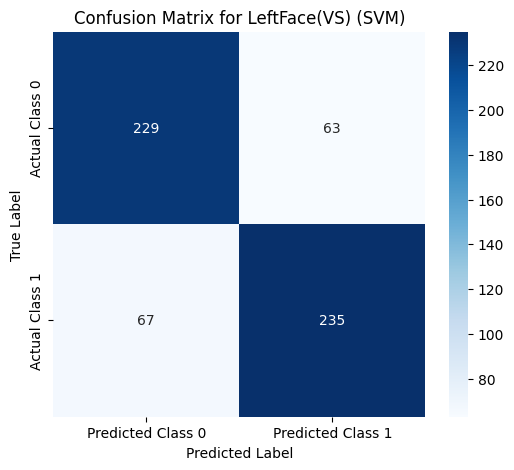

In [ ]:
#Creating heatmap for confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Class 0', 'Predicted Class 1'],
            yticklabels=['Actual Class 0', 'Actual Class 1'])

#giving labels, title, and displaying the plot
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for LeftFace(VS) (SVM)')
plt.show()

**Area Under the Curve Score**

In [ ]:
#Getting the decision function scores for the test set
y_scores = svm.decision_function(X_test)

#Computing False Positive Rate (FPR), True Positive Rate (TPR), and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

#Calculating AUC
roc_auc = auc(fpr, tpr)
print(f'AUC: {roc_auc:.2f}')

AUC: 0.85


**ROC (Receiver Operating Characteristic) Curve**

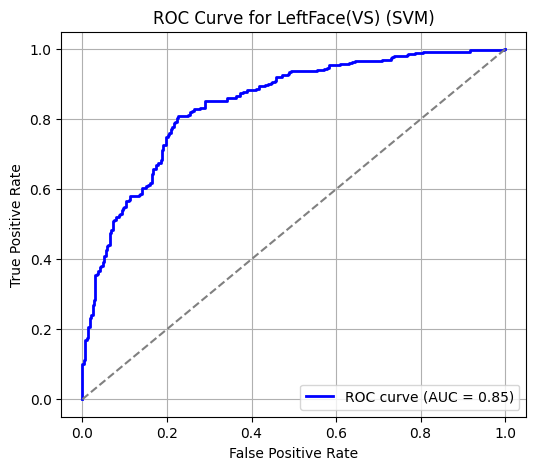

In [ ]:
#Plotting the ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

#Adding labels, title, and legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for LeftFace(VS) (SVM)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()